# Task 4.3: Machine Learning Model Development for Move Tickers (Group)

## Group Information

Please enter your group details below:

**Group Name:** `<Your Group Number Here>`  



This notebook guides you through Task 4.3, where you will design, implement, and validate machine learning models using financial time series data for Move Tickers.

You are encouraged to explore one or more of the following directions, depending on your project’s business problem: forecasting, classification, clustering, anomaly detection, or a hybrid approach.

📌 **Note:** This task is directly connected to your previously completed proposal and your database from Task 1.2.
---

## ⚠️ Important Note:


Do not change the order of the steps in this template. However, feel free to **add extra cells** where necessary to split each step into smaller parts or to provide additional explanations. For example, you may add cells to explain your reasoning behind decisions, show intermediate results, or clarify what you considered at each stage of the process.


## 🔍  Step 1: Review Your Problem Statement

Briefly revisit and summarise the problem statement from your group proposal.
This will help keep your objectives focused and aligned throughout the modelling task.

👉 Include your business question or challenge and explain its relevance to Move Tickers.

In [1]:
# Provide a brief explanation here
# Keep it concise and to the point
# This should summarize your main idea

##  🗄️ Step 2: Load and Explore Data

You should load the data that you have stored in the SQL database table you created during **Task 1.2: Database Creation**. We have included a template of how to do this below with SQLAlchemy, make sure to fill in the missing parts.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sqlalchemy import create_engine
from datetime import datetime
import pywt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Replace with your actual database connection details
db_params = {
    'host': '194.171.191.226',
    'port': '3432',
    'database': 'group_6_warehouse',
    'user': 'group_6_user',
    'password': 'group_6_blockd25'
}

db_url = f"postgresql://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

engine = create_engine(db_url, echo=True)
data = pd.read_sql_query("SELECT * FROM fact_company_daily_metrics", engine)

2025-06-13 13:26:22,340 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2025-06-13 13:26:22,340 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-13 13:26:22,352 INFO sqlalchemy.engine.Engine select current_schema()
2025-06-13 13:26:22,353 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-13 13:26:22,364 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2025-06-13 13:26:22,365 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-13 13:26:22,377 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-06-13 13:26:22,377 INFO sqlalchemy.engine.Engine SELECT * FROM fact_company_daily_metrics
2025-06-13 13:26:22,378 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-06-13 13:26:23,273 INFO sqlalchemy.engine.Engine ROLLBACK


#### 📌 **Note:** You must run the above cell at least once to retrieve the data from your database. After running it once, you can save the data locally, which will prevent the need to reconnect to the server when working remotely, especially if you encounter access issues to the server.

## 📊 Step 3: Preprocessing

Clean and prepare your data for machine learning. This may involve:
- Handling missing values and outliers
- Feature engineering (e.g., lag variables, moving averages)
- Normalisation or scaling
- Encoding categorical variables (if applicable)

In [4]:
data = pd.read_csv('fact_dataset.csv')

In [3]:
data.columns

Index(['date_value', 'company_prefix', 'open_value', 'close_value',
       'low_value', 'high_value', 'volume', 'unemployment_rate', 'gdp_growth',
       'inflation_cpi', 'stock_market_volatility_vix_index',
       'interest_rate_fed_funds', 'return_1d', 'return_3d', 'sma_10', 'sma_50',
       'sma_diff', 'rsi_14', 'atr', 'macd'],
      dtype='object')

## Trend Prediction Model - Data Preprocessing

### Macroeconomic Indicators Preprocessing

To begin the data preparation process, I first created a new dataset named macroeconomic_news by extracting only the relevant columns—specifically, the date and the macroeconomic indicators of interest: `inflation_cpi`, `unemployment_rate`, `stock_market_volatility_vix_index`, `gdp_growth` and `interest_rate_fed_funds`. This allowed for a focused analysis on the most impactful economic variables while reducing unnecessary complexity in the dataset.

In [6]:
# List of macroeconomic indicator (columns) to keep
macro_columns = [
    'date_value',
    'unemployment_rate',
    'gdp_growth',
    'inflation_cpi',
    'stock_market_volatility_vix_index',
    'interest_rate_fed_funds'
]

# Create a copy with only the selected columns
macroeconomic_news = data[macro_columns].copy()

# Drop duplicate rows for each date_value, keeping only one row per date
macroeconomic_news = macroeconomic_news.drop_duplicates(subset=['date_value'])

macroeconomic_news = macroeconomic_news.sort_values(by='date_value', ascending=True)

In [7]:
macroeconomic_news.head(10)

,date_value,unemployment_rate,gdp_growth,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
5535,2015-02-17,5.441579,NaN,235.758850,15.80,0.108784
5536,2015-02-18,5.438013,NaN,235.781281,15.45,0.108789
5537,2015-02-19,5.434462,NaN,235.803055,15.29,0.108808
3914,2015-02-20,5.430927,NaN,235.824127,14.30,0.108843
3915,2015-02-23,5.420430,NaN,235.882767,14.56,0.109050
3916,2015-02-24,5.416970,NaN,235.900665,13.69,0.109156
3917,2015-02-25,5.413530,NaN,235.917679,13.84,0.109282
3918,2015-02-26,5.410113,NaN,235.933746,13.91,0.109428
3919,2015-02-27,5.406718,NaN,235.948853,13.34,0.109596
3920,2015-03-02,5.396682,NaN,235.987991,13.04,0.110237


We drop the macroeconomic indicators from the initial dataframe so we would be able to merge them at the end of this data cleaning process.

In [8]:
cols_to_drop = [
    'unemployment_rate',
    'gdp_growth',
    'inflation_cpi',
    'stock_market_volatility_vix_index',
    'interest_rate_fed_funds'
]

data = data.drop(columns=cols_to_drop)

Upon loading the data, I initiated the cleaning process by printing the number of missing values for each column. It quickly became apparent that the columns `unemployment_rate`, `inflation_cpi`, and `interest_rate_fed_funds` only contained values on the first day of each month, leaving the rest of the days with missing entries. To address this and ensure a smooth, continuous time series, I applied *spline interpolation* to these columns. Spline interpolation is particularly suitable here because it provides a smooth transition between monthly data points, preserving the underlying economic trends without introducing abrupt changes. 

For the remaining columns, I handled missing data individually. The     `stock_market_volatility_vix_index` column had **107 missing values**, which I filled using *forward filling*. This approach is appropriate for financial time series like the VIX, as it assumes that the most recent available value remains valid until a new value is observed, thereby maintaining continuity in the data. 

! This process has been done in a separate notebook before creating the initial database table, then used the cleaned version of the macroeconomic indicators to make the process smoother. This notebook is linked here for seeing how we preprocessed this part of the dataset.

In [9]:
print(macroeconomic_news.isna().sum())

date_value                              0
unemployment_rate                       1
gdp_growth                           2515
inflation_cpi                           1
stock_market_volatility_vix_index       1
interest_rate_fed_funds                 1
dtype: int64


The `gdp_growth` column was dropped altogether, as it contained a significant number of missing values and there was no efficient or reliable method to impute them.

In [10]:
macroeconomic_news.drop(columns=['gdp_growth'], inplace=True)

As we can see, there are still one missing values for four features, first we willl check where this NaN value is placed. After analysis, the missing value seem to be at the end of the dataframe, on the last row, so we will just drop the row entirely as it would not impact the results significantly.

In [11]:
missing_dates = macroeconomic_news[
    macroeconomic_news[
        ['unemployment_rate', 'inflation_cpi', 'stock_market_volatility_vix_index', 'interest_rate_fed_funds']
    ].isnull().any(axis=1)
][['date_value', 'unemployment_rate', 'inflation_cpi', 'stock_market_volatility_vix_index', 'interest_rate_fed_funds']]
print(missing_dates)


      date_value  unemployment_rate  inflation_cpi  \
2485  2025-02-13                NaN            NaN   

      stock_market_volatility_vix_index  interest_rate_fed_funds  
2485                                NaN                      NaN  


In [12]:
macroeconomic_news.tail()

,date_value,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
2481,2025-02-07,3.872113,320.825684,16.540001,4.148420
2482,2025-02-10,3.856521,320.948151,15.810000,4.132139
2483,2025-02-11,3.851057,320.988037,16.020000,4.126632
2484,2025-02-12,3.845454,321.027405,15.890000,4.121083
2485,2025-02-13,NaN,NaN,NaN,NaN


In [13]:
# Dropping the last row
macroeconomic_news = macroeconomic_news.iloc[:-1]

In [14]:
# Sort the dataset
macroeconomic_news_sorted = macroeconomic_news.sort_values(by='date_value', ascending=True).reset_index(drop=True)

# Merge the initial 'data' with the cleaned 'macroeconomic_news' on 'date_value' using an inner join to keep only the dates present in macroeconomic_news
data = data.merge(macroeconomic_news_sorted, on='date_value', how='inner')

data = data.sort_values(by='date_value', ascending=True).reset_index(drop=True)

In [15]:
data.head()

,date_value,company_prefix,open_value,close_value,low_value,high_value,volume,return_1d,return_3d,sma_10,sma_50,sma_diff,rsi_14,atr,macd,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds
0,2015-02-17,AAPL,31.8725,31.9575,31.73,32.22,252516820.0,NaN,NaN,31.9575,31.9575,0.0,100.0,0.490,0.0,5.441579,235.758850,15.80,0.108784
1,2015-02-17,KLAC,63.6700,63.9300,63.50,64.15,1068650.0,NaN,NaN,63.9300,63.9300,0.0,100.0,0.650,0.0,5.441579,235.758850,15.80,0.108784
2,2015-02-17,QCOM,70.7600,70.8000,70.46,70.91,8764262.0,NaN,NaN,70.8000,70.8000,0.0,100.0,0.450,0.0,5.441579,235.758850,15.80,0.108784
3,2015-02-17,MSFT,43.9700,43.5800,43.19,44.00,33695149.0,NaN,NaN,43.5800,43.5800,0.0,100.0,0.810,0.0,5.441579,235.758850,15.80,0.108784
4,2015-02-18,KLAC,63.7100,64.2900,63.63,64.67,1014879.0,0.563116,NaN,64.1100,64.1100,0.0,100.0,0.845,0.0,5.438013,235.781281,15.45,0.108789


In [16]:
data.isnull().sum()

date_value                            0
company_prefix                        0
open_value                            0
close_value                           0
low_value                             0
high_value                            0
volume                                0
return_1d                             6
return_3d                            18
sma_10                                0
sma_50                                0
sma_diff                              0
rsi_14                                0
atr                                   0
macd                                  0
unemployment_rate                     0
inflation_cpi                         0
stock_market_volatility_vix_index     0
interest_rate_fed_funds               0
dtype: int64

### Predictive Features - Preprocessing

In [17]:
# Get next day's close value for each company
data['Tomorrow'] = data.groupby('company_prefix')['close_value'].shift(-1)

# Set target: 1 if price goes up next day, else 0
data['Target'] = (data['Tomorrow'] > data['close_value']).astype(int)


In [18]:
# List of company prefixes
companies = ['AAPL', 'MSFT', 'PLTR', 'KLAC', 'QCOM', 'CRWD']

# Columns to keep
cols = [
    'date_value', 'open_value', 'low_value', 'high_value', 'close_value', 'volume',
    'rsi_14', 'macd', 'atr', 'unemployment_rate', 'inflation_cpi',
    'stock_market_volatility_vix_index', 'interest_rate_fed_funds', 'Tomorrow', 'Target'
]

# Create a dictionary to hold the DataFrames
company_dfs = {}

for prefix in companies:
    df = data.loc[data['company_prefix'] == prefix, cols].copy()
    df['date_value'] = pd.to_datetime(df['date_value']).dt.date  # Ensure datetime type
    df.set_index('date_value', inplace=True)             # Set as index
    company_dfs[prefix] = df

# Access individual DataFrames
AAPL_data = company_dfs['AAPL']
MSFT_data = company_dfs['MSFT']
PLTR_data = company_dfs['PLTR']
KLAC_data = company_dfs['KLAC']
QCOM_data = company_dfs['QCOM']
CRWD_data = company_dfs['CRWD']


In [19]:
# Example dataset
AAPL_data.head()

,open_value,low_value,high_value,close_value,volume,rsi_14,macd,atr,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds,Tomorrow,Target
date_value,,,,,,,,,,,,,,
2015-02-17,31.8725,31.7300,32.2200,31.9575,252516820.0,100.000000,0.0,0.49000,5.441579,235.758850,15.80,0.108784,32.1788,1
2015-02-18,31.9063,31.8625,32.1950,32.1788,179558052.0,100.000000,0.0,0.41125,5.438013,235.781281,15.45,0.108789,32.1125,0
2015-02-19,32.1200,32.0825,32.2575,32.1125,149449524.0,76.947149,0.0,0.33250,5.434462,235.803055,15.29,0.108808,32.3738,1
2015-02-20,32.1550,32.0125,32.3750,32.3738,195793676.0,87.921297,0.0,0.34000,5.430927,235.824127,14.30,0.108843,33.2500,1
2015-02-23,32.5050,32.4150,33.2500,33.2500,283896440.0,95.347695,0.0,0.44724,5.420430,235.882767,14.56,0.109050,33.0425,0


 This part would be helpful later for splitting the data depending on the dates the ticker had been added to the NASDAQ 100 list.

In [20]:
# List of (ticker, DataFrame) pairs for multiple companies
datasets = [
    ("AAPL", AAPL_data),
    ("CRWD", CRWD_data),
    ("MSFT", MSFT_data),
    ("KLAC", KLAC_data),
    ("PLTR", PLTR_data),
    ("QCOM", QCOM_data)
]

# Print min and max index date range for each dataset
for name, df in datasets:
    print(f"Dataset: {name}")
    print(f"Min index: {df.index.min()}")
    print(f"Max index: {df.index.max()}\n")



Dataset: AAPL
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: CRWD
Min index: 2019-06-12
Max index: 2025-02-12

Dataset: MSFT
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: KLAC
Min index: 2015-02-17
Max index: 2025-02-12

Dataset: PLTR
Min index: 2020-09-30
Max index: 2025-02-12

Dataset: QCOM
Min index: 2015-02-17
Max index: 2025-02-12



## Clustering Model - Preprocessing

In [5]:
data_clustering = data.copy()

In [14]:
data_clustering.isna().sum()

date_value                               0
company_prefix                           0
open_value                               0
close_value                              0
low_value                                0
high_value                               0
volume                                   0
unemployment_rate                        6
gdp_growth                           12587
inflation_cpi                            6
stock_market_volatility_vix_index        6
interest_rate_fed_funds                  6
return_1d                                6
return_3d                               18
sma_10                                   0
sma_50                                   0
sma_diff                                 0
rsi_14                                   0
atr                                      0
macd                                     0
daily_return                             1
volatility_30                           30
max_drawdown                            59
avg_volume 

# 🤖 Step 4. Model Development
Train machine learning models based on your selected approach. Feel free to experiment with different algorithms.


# Next-Day Trend Predictions Models

## I. Machine Learning Models

In [21]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])  # train model on train set
    preds = model.predict(test[predictors])        # predict on test set
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis=1)  # combine true & predicted
    return combined

### AAPL Model

#### 1. Baseline Model - RandomForestClassifier

RandomForestClassifier is particularly useful for next-day stock trend prediction due to its ability to handle noisy, high-dimensional financial data while mitigating overfitting. By aggregating predictions from multiple decision trees trained on random data subsets and features, the model captures complex nonlinear relationships between variables like price movements, technical indicators, and market sentiment.

In [22]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=42)

train = AAPL_data.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test = AAPL_data.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

predictors = ['open_value', 'high_value', 'low_value', 'close_value', 'volume']

# Use predict() function to train on train and predict on test, returning true & predicted labels
results_train = predict(train, train, predictors, model)
results_test = predict(train, test, predictors, model)    

#### 2. Baseline Model + Additional Features - RandomForestClassifier

In [23]:
# Make a copy of the original data
AAPL_data_addfeat = AAPL_data.copy()

# Define the horizons and initial predictors
horizons = [2, 5, 60, 250]
new_predictors = ['inflation_cpi', 'interest_rate_fed_funds', 'macd', 'atr']

# Loop through each horizon to create new features
for horizon in horizons:
    # Rolling average of 'close_value'
    rolling_avg = AAPL_data_addfeat['close_value'].rolling(horizon).mean()

    # Close ratio: current close value divided by rolling average
    ratio_column = f'Close_Ratio_{horizon}'
    AAPL_data_addfeat[ratio_column] = AAPL_data_addfeat['close_value'] / rolling_avg

    # Trend: sum of 'Target' values over the past 'horizon' days, shifted to avoid lookahead bias
    trend_column = f'Trend_{horizon}'
    AAPL_data_addfeat[trend_column] = AAPL_data_addfeat['Target'].shift(1).rolling(horizon).sum()

    # Add new feature names to the predictors list
    new_predictors += [ratio_column, trend_column]

AAPL_data_addfeat = AAPL_data_addfeat.dropna()

In [24]:
model_v2 = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)

train_addfeat = AAPL_data_addfeat.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test_addfeat = AAPL_data_addfeat.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

results_train_addfeat = predict(train_addfeat, train_addfeat, new_predictors, model_v2)
results_test_addfeat = predict(train_addfeat, test_addfeat, new_predictors, model_v2)  

#### 3. RandomForestClassifier with Wavelet Denoising

Wavelet denoising is used to reduce noise in financial time series while preserving important patterns like trends and sudden changes. Stock price data is often noisy due to market micro-movements, irregular trades, or external shocks. This noise can mislead machine learning models, especially when predicting short-term trends like next-day price movement. By applying wavelet denoising, I smooth out high-frequency noise without distorting the underlying structure, helping the model focus on meaningful signals that are more likely correlated with actual stock trends (up/down).

In [25]:
AAPL_data_wd = AAPL_data.copy()

def wavelet_denoise(series, wavelet='db4', level=3):
    coeffs = pywt.wavedec(series, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(series)))
    coeffs_thresholded = [coeffs[0]] + [pywt.threshold(c, threshold, 'soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs_thresholded, wavelet)[:len(series)]

In [26]:
# Feature Engineering
AAPL_data_wd['Denoised_Close'] = wavelet_denoise(AAPL_data_wd['close_value'])
AAPL_data_wd['Returns'] = AAPL_data_wd['Denoised_Close'].pct_change()
AAPL_data_wd['RSI'] = 100 - 100/(1 + AAPL_data_wd['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             AAPL_data_wd['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
AAPL_data_wd['Tomorrow'] = AAPL_data_wd['Denoised_Close'].shift(-1) 
AAPL_data_wd['Target'] = (AAPL_data_wd['Tomorrow'] > AAPL_data_wd['Denoised_Close']).astype(int)
AAPL_data_wd.dropna(inplace=True)

# Splitting the data
train_v3 = AAPL_data_wd.loc[:datetime.strptime('2022-12-31', '%Y-%m-%d').date()]
test_v3 = AAPL_data_wd.loc[datetime.strptime('2023-01-01', '%Y-%m-%d').date():]

X_train = train_v3[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train = train_v3['Target']  
X_test = test_v3[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test = test_v3['Target'] 

In [27]:
model_v3 = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_v3.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

### CRWD Model

In [28]:
# Feature Engineering
CRWD_data['Denoised_Close'] = wavelet_denoise(CRWD_data['close_value'])
CRWD_data['Returns'] = CRWD_data['Denoised_Close'].pct_change()
CRWD_data['RSI'] = 100 - 100/(1 + CRWD_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             CRWD_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
CRWD_data['Tomorrow'] = CRWD_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
CRWD_data['Target'] = (CRWD_data['Tomorrow'] > CRWD_data['Denoised_Close']).astype(int)
CRWD_data.dropna(inplace=True)

#Splitting the data
train_crwd = CRWD_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_crwd = CRWD_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_crwd = train_crwd[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_crwd = train_crwd['Target']  
X_test_crwd = test_crwd[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_crwd = test_crwd['Target']  

model_crwd = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)
model_crwd.fit(X_train_crwd, y_train_crwd)

RandomForestClassifier(class_weight='balanced', min_samples_split=50,
                       n_estimators=200, random_state=42)

### KLAC Model

In [29]:
# Feature Engineering
KLAC_data['Denoised_Close'] = wavelet_denoise(KLAC_data['close_value'])
KLAC_data['Returns'] = KLAC_data['Denoised_Close'].pct_change()
KLAC_data['RSI'] = 100 - 100/(1 + KLAC_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             KLAC_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
KLAC_data['Tomorrow'] = KLAC_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
KLAC_data['Target'] = (KLAC_data['Tomorrow'] > KLAC_data['Denoised_Close']).astype(int)
KLAC_data.dropna(inplace=True)

# Splitting the data
train_klac = KLAC_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_klac = KLAC_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_klac = train_klac[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_klac = train_klac['Target']  
X_test_klac = test_klac[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_klac = test_klac['Target']  

model_klac = RandomForestClassifier(n_estimators=200, min_samples_split=50, class_weight='balanced', random_state=42)
model_klac.fit(X_train_klac, y_train_klac)

RandomForestClassifier(class_weight='balanced', min_samples_split=50,
                       n_estimators=200, random_state=42)

### MSFT Model

In [30]:
# Feature Engineering
MSFT_data['Denoised_Close'] = wavelet_denoise(MSFT_data['close_value'])
MSFT_data['Returns'] = MSFT_data['Denoised_Close'].pct_change()
MSFT_data['RSI'] = 100 - 100/(1 + MSFT_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             MSFT_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
MSFT_data['Tomorrow'] = MSFT_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
MSFT_data['Target'] = (MSFT_data['Tomorrow'] > MSFT_data['Denoised_Close']).astype(int)
MSFT_data.dropna(inplace=True)

#Splitting the data
train_msft = MSFT_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_msft = MSFT_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_msft = train_msft[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_msft = train_msft['Target'] 
X_test_msft = test_msft[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_msft = test_msft['Target']  

model_msft = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_msft.fit(X_train_msft, y_train_msft)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

### PLTR Model

In [31]:
# Feature Engineering
PLTR_data['Denoised_Close'] = wavelet_denoise(PLTR_data['close_value'])
PLTR_data['Returns'] = PLTR_data['Denoised_Close'].pct_change()
PLTR_data['RSI'] = 100 - 100/(1 + PLTR_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             PLTR_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
PLTR_data['Tomorrow'] = PLTR_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
PLTR_data['Target'] = (PLTR_data['Tomorrow'] > PLTR_data['Denoised_Close']).astype(int)
PLTR_data.dropna(inplace=True)

# Splitting the data
train_pltr = PLTR_data.loc[:datetime.strptime('2024-02-13', '%Y-%m-%d').date()]
test_pltr = PLTR_data.loc[datetime.strptime('2024-02-14', '%Y-%m-%d').date():]

X_train_pltr = train_pltr[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_pltr = train_pltr['Target'] 
X_test_pltr = test_pltr[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_pltr = test_pltr['Target']

model_pltr = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_pltr.fit(X_train_pltr, y_train_pltr)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

### QCOM Model

In [32]:
# Feature Engineering
QCOM_data['Denoised_Close'] = wavelet_denoise(QCOM_data['close_value'])
QCOM_data['Returns'] = QCOM_data['Denoised_Close'].pct_change()
QCOM_data['RSI'] = 100 - 100/(1 + QCOM_data['Denoised_Close'].diff().clip(lower=0).rolling(14).mean()/
                             QCOM_data['Denoised_Close'].diff().clip(upper=0).abs().rolling(14).mean())
QCOM_data['Tomorrow'] = QCOM_data['Denoised_Close'].shift(-1)  # Use denoised close for consistency
QCOM_data['Target'] = (QCOM_data['Tomorrow'] > QCOM_data['Denoised_Close']).astype(int)
QCOM_data.dropna(inplace=True)

# Splitting the data
train_qcom = QCOM_data.loc[:datetime.strptime('2023-02-12', '%Y-%m-%d').date()]
test_qcom = QCOM_data.loc[datetime.strptime('2023-02-13', '%Y-%m-%d').date():]

X_train_qcom = train_qcom[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_train_qcom = train_qcom['Target']  
X_test_qcom = test_qcom[['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']]
y_test_qcom = test_qcom['Target'] 

model_qcom = RandomForestClassifier(n_estimators=200, min_samples_split=100, class_weight='balanced', random_state=42)
model_qcom.fit(X_train_qcom, y_train_qcom)

RandomForestClassifier(class_weight='balanced', min_samples_split=100,
                       n_estimators=200, random_state=42)

## II. Rule-based Models

In [33]:
data_rulebased = data.copy()

In [34]:
# Convert 'date_value' to datetime if it's not already
data_rulebased['date_value'] = pd.to_datetime(data_rulebased['date_value'])

# Set 'date_value' as the index
data_rulebased.set_index('date_value', inplace=True)

### 1. Buy & Hold: Buy at the start, hold until the end

In [35]:
data_rulebased.head()

,company_prefix,open_value,close_value,low_value,high_value,volume,return_1d,return_3d,sma_10,sma_50,sma_diff,rsi_14,atr,macd,unemployment_rate,inflation_cpi,stock_market_volatility_vix_index,interest_rate_fed_funds,Tomorrow,Target
date_value,,,,,,,,,,,,,,,,,,,,
2015-02-17,AAPL,31.8725,31.9575,31.73,32.22,252516820.0,NaN,NaN,31.9575,31.9575,0.0,100.0,0.490,0.0,5.441579,235.758850,15.80,0.108784,32.1788,1
2015-02-17,KLAC,63.6700,63.9300,63.50,64.15,1068650.0,NaN,NaN,63.9300,63.9300,0.0,100.0,0.650,0.0,5.441579,235.758850,15.80,0.108784,64.2900,1
2015-02-17,QCOM,70.7600,70.8000,70.46,70.91,8764262.0,NaN,NaN,70.8000,70.8000,0.0,100.0,0.450,0.0,5.441579,235.758850,15.80,0.108784,70.5400,0
2015-02-17,MSFT,43.9700,43.5800,43.19,44.00,33695149.0,NaN,NaN,43.5800,43.5800,0.0,100.0,0.810,0.0,5.441579,235.758850,15.80,0.108784,43.5300,0
2015-02-18,KLAC,63.7100,64.2900,63.63,64.67,1014879.0,0.563116,NaN,64.1100,64.1100,0.0,100.0,0.845,0.0,5.438013,235.781281,15.45,0.108789,64.6600,1


In [36]:
def buy_and_hold_from_cleaned_data(data_rulebased, company_prefix, investment):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")

    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Buy at first available date, sell at last
    buy_price = data_rulebased['close_value'].iloc[0]
    sell_price = data_rulebased['close_value'].iloc[-1]
    buy_date = data_rulebased.index[0].date()
    sell_date = data_rulebased.index[-1].date()

    num_shares = investment // buy_price
    remaining_cash = investment - (num_shares * buy_price)
    final_value = (num_shares * sell_price) + remaining_cash
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nBuy & Hold Results for {company_prefix}:")
    print(f"Buy Date: {buy_date} | Buy Price: ${buy_price:.2f}")
    print(f"Sell Date: {sell_date} | Sell Price: ${sell_price:.2f}")
    print(f"Shares Bought: {num_shares}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    # Portfolio value over time
    data_rulebased['Portfolio Value'] = (data_rulebased['close_value'] * num_shares) + remaining_cash

    return data_rulebased

In [37]:
def plot_portfolio_value(data_rulebased, company_prefix):
    plt.figure(figsize=(10, 6))
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value')
    plt.title(f"Portfolio Value Over Time (Buy & Hold) - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Buy & Hold Results for AAPL:
Buy Date: 2015-02-17 | Buy Price: $31.96
Sell Date: 2025-02-12 | Sell Price: $236.87
Shares Bought: 31.0
Final Portfolio Value: $7352.29
Total Profit: $6352.29
ROI: 635.23%



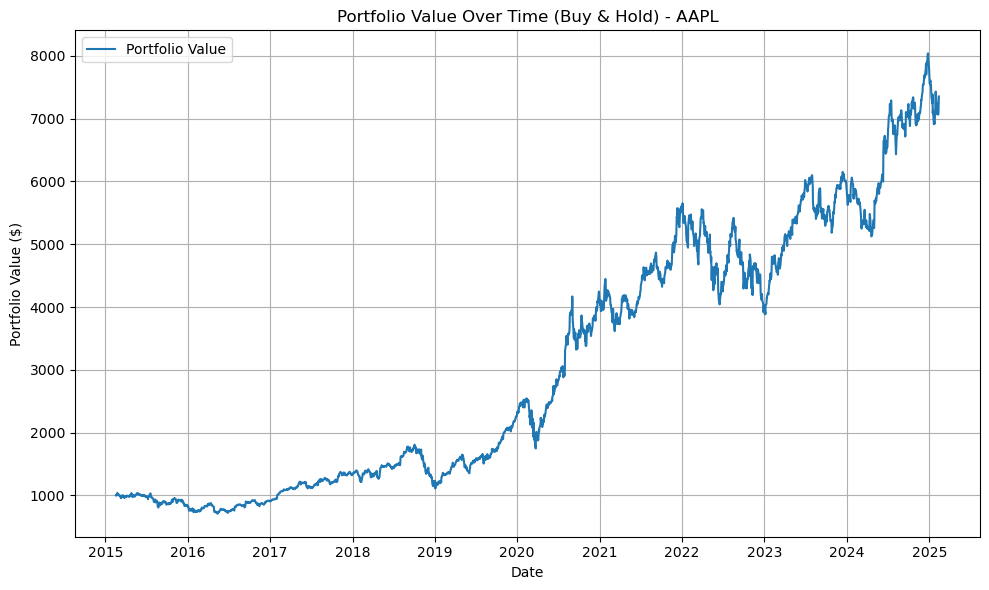

In [38]:
# Example usage 
company_prefix = 'AAPL'
investment = 1000

results_df = buy_and_hold_from_cleaned_data(data_rulebased, company_prefix, investment)
if results_df is not None:
    plot_portfolio_value(results_df, company_prefix)

### 2. Moving Average Crossover

Simulating a trading strategy where you "buy" a stock when the short-term moving average crosses above the long-term moving average (a bullish signal) and "sell" when it crosses below (a bearish signal)

In [42]:
def moving_average_crossover(data_rulebased, company_prefix, investment):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")
        return None

    # Ensure the index is datetime and sorted
    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Use existing columns
    data_rulebased['short_ma'] = data_rulebased['sma_10']
    data_rulebased['long_ma'] = data_rulebased['sma_50']
    data_rulebased['sma_diff'] = data_rulebased['sma_diff']

    # Initialize signal column with zeros
    data_rulebased['signal'] = 0

    # Calculate buy signals (1) where sma_diff crosses from <=0 to >0
    buy_signals = ((data_rulebased['sma_diff'].values[1:] > 0) & (data_rulebased['sma_diff'].values[:-1] <= 0)).astype(int)
    # Calculate sell signals (-1) where sma_diff crosses from >=0 to <0
    sell_signals = ((data_rulebased['sma_diff'].values[1:] < 0) & (data_rulebased['sma_diff'].values[:-1] >= 0)).astype(int)
    # Assign buy and sell signals using .loc to avoid chained assignment
    data_rulebased.loc[data_rulebased.index[1:], 'signal'] = buy_signals - sell_signals

    # Simulate trading
    cash = investment
    shares = 0
    portfolio_values = []
    positions = []

    for idx, row in data_rulebased.iterrows():
        # Buy signal
        if row['signal'] == 1 and cash > 0:
            shares = cash // row['close_value']
            cash -= shares * row['close_value']
        # Sell signal
        elif row['signal'] == -1 and shares > 0:
            cash += shares * row['close_value']
            shares = 0
        # Calculate portfolio value at each step
        portfolio_value = cash + shares * row['close_value']
        portfolio_values.append(portfolio_value)
        positions.append(shares)

    data_rulebased['Portfolio Value'] = portfolio_values
    data_rulebased['Shares Held'] = positions

    # Final stats
    final_value = data_rulebased['Portfolio Value'].iloc[-1]
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nMoving Average Crossover Results for {company_prefix}:")
    print(f"Initial Investment: ${investment:.2f}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    return data_rulebased

In [43]:
def plot_ma_crossover(data_rulebased, company_prefix):
    plt.figure(figsize=(12, 7))
    plt.plot(data_rulebased.index, data_rulebased['close_value'], label='Close Price', color='black')
    plt.plot(data_rulebased.index, data_rulebased['short_ma'], label='SMA 10', color='blue', alpha=0.7)
    plt.plot(data_rulebased.index, data_rulebased['long_ma'], label='SMA 50', color='red', alpha=0.7)
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value', color='green', linestyle='--', alpha=0.6)
    plt.title(f"Moving Average Crossover Strategy - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Price / Portfolio Value ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Moving Average Crossover Results for PLTR:
Initial Investment: $1000.00
Final Portfolio Value: $6517.49
Total Profit: $5517.49
ROI: 551.75%



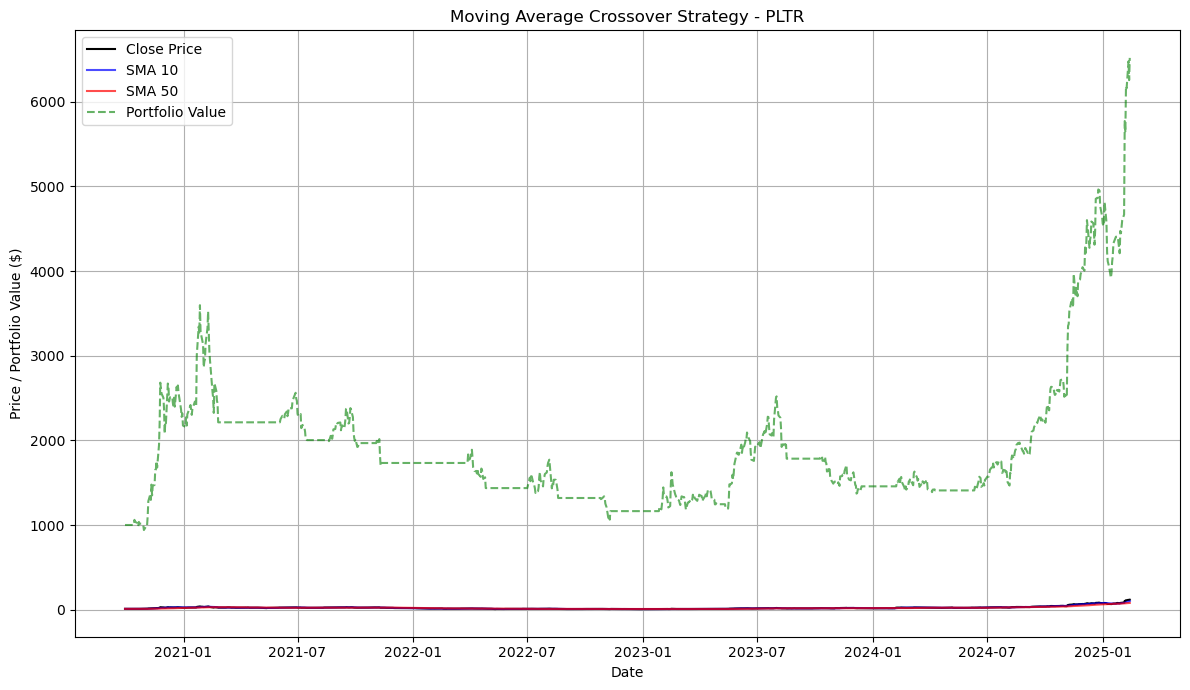

In [44]:
# Example usage
company_prefix = 'PLTR'
investment = 1000
results_ma = moving_average_crossover(data_rulebased, company_prefix, investment)

if results_ma is not None:
    plot_ma_crossover(results_ma, company_prefix)

### 3. RSI Based

In [48]:
def rsi_based_strategy(data_rulebased, company_prefix, investment, rsi_column='rsi_14', rsi_buy_threshold=30, rsi_sell_threshold=70):
    # Filter for the selected ticker
    data_rulebased = data_rulebased[data_rulebased['company_prefix'] == company_prefix].copy()
    if data_rulebased.empty:
        print(f"No data found for ticker {company_prefix}.")
        return None

    # Ensure the index is datetime and sorted
    if not isinstance(data_rulebased.index, pd.DatetimeIndex):
        data_rulebased.index = pd.to_datetime(data_rulebased.index)
    data_rulebased = data_rulebased.sort_index()

    # Initialize signal column: 1 for buy, -1 for sell, 0 for hold
    data_rulebased['signal'] = 0

    # Buy: RSI crosses above buy threshold (oversold)
    buy_signals = ((data_rulebased[rsi_column].values[1:] > rsi_buy_threshold) & (data_rulebased[rsi_column].values[:-1] <= rsi_buy_threshold)).astype(int)
    # Sell: RSI crosses below sell threshold (overbought)
    sell_signals = ((data_rulebased[rsi_column].values[1:] < rsi_sell_threshold) & (data_rulebased[rsi_column].values[:-1] >= rsi_sell_threshold)).astype(int)

    # Assign signals using .loc to avoid chained assignment
    data_rulebased.loc[data_rulebased.index[1:], 'signal'] = buy_signals - sell_signals

    # Simulate trading
    cash = investment
    shares = 0
    portfolio_values = []
    positions = []

    for idx, row in data_rulebased.iterrows():
        # Buy signal
        if row['signal'] == 1 and cash > 0:
            shares = cash // row['close_value']
            cash -= shares * row['close_value']
        # Sell signal
        elif row['signal'] == -1 and shares > 0:
            cash += shares * row['close_value']
            shares = 0
        # Calculate portfolio value at each step
        portfolio_value = cash + shares * row['close_value']
        portfolio_values.append(portfolio_value)
        positions.append(shares)

    data_rulebased['Portfolio Value'] = portfolio_values
    data_rulebased['Shares Held'] = positions

    # Final stats
    final_value = data_rulebased['Portfolio Value'].iloc[-1]
    profit = final_value - investment
    roi = (profit / investment) * 100

    print(f"\nRSI-Based Strategy Results for {company_prefix}:")
    print(f"Initial Investment: ${investment:.2f}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Profit: ${profit:.2f}")
    print(f"ROI: {roi:.2f}%\n")

    return data_rulebased

In [49]:
def plot_rsi_strategy(data_rulebased, company_prefix):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 7))
    plt.plot(data_rulebased.index, data_rulebased['close_value'], label='Close Price', color='black')
    plt.plot(data_rulebased.index, data_rulebased['rsi_14'], label='RSI 14', color='purple', alpha=0.7)
    plt.axhline(30, color='green', linestyle='--', label='RSI Buy Threshold (30)')
    plt.axhline(70, color='red', linestyle='--', label='RSI Sell Threshold (70)')
    plt.plot(data_rulebased.index, data_rulebased['Portfolio Value'], label='Portfolio Value', color='green', linestyle='--', alpha=0.6)
    plt.title(f"RSI-Based Strategy - {company_prefix}")
    plt.xlabel("Date")
    plt.ylabel("Price / RSI / Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


RSI-Based Strategy Results for CRWD:
Initial Investment: $1000.00
Final Portfolio Value: $8.13
Total Profit: $-991.87
ROI: -99.19%



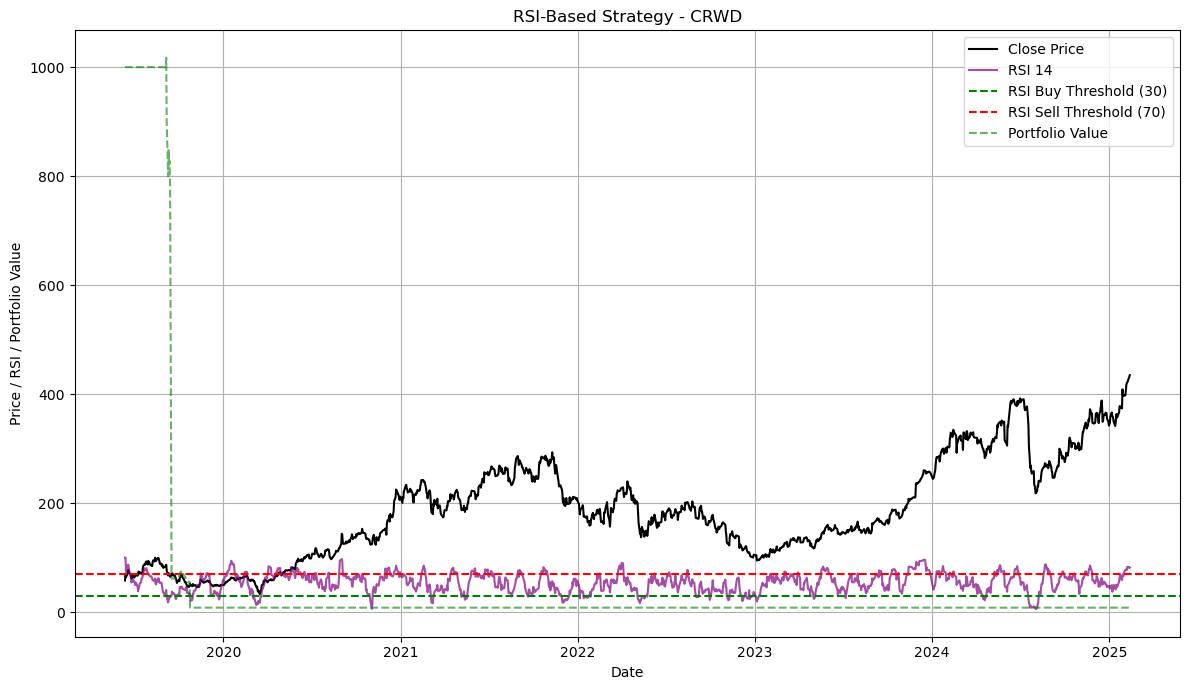

In [50]:
# Example usage (assuming cleaned_data is already loaded)
company_prefix = 'CRWD'
investment = 1000
results_rsi = rsi_based_strategy(data_rulebased, company_prefix, investment)
if results_rsi is not None:
    plot_rsi_strategy(results_rsi, company_prefix)

# Clustering Model

# 📈 Step 5: Model Evaluation

Evaluate your models using suitable metrics for your problem, such as:
- Accuracy, Precision, Recall, F1-score (for classification)
- RMSE, MAE, R-squared (for regression)
- Silhouette Score, Davies-Bouldin Index (for clustering)

Ensure proper validation techniques such as cross-validation or backtesting.


📌  In addition to evaluating the performance of your developed model, compute a baseline performance metric (e.g., using a naive forecast, mean predictor, or a simple model). This baseline will serve as a reference point to help you assess how well your model performs compared to a simple alternative.


# Next-Day Trend Predictions Evaluation

In [ ]:
# Evaluation function
def evaluate(true, preds, dataset_name):
    print(f"Evaluation on {dataset_name}:")
    print(f"  Accuracy:  {accuracy_score(true, preds):.4f}")
    print(f"  Precision: {precision_score(true, preds):.4f}")
    print(f"  Recall:    {recall_score(true, preds):.4f}")
    print(f"  F1 Score:  {f1_score(true, preds):.4f}")
    print()

## AAPL Models

### 1. AAPL - baseline

In [ ]:
# Evaluate
evaluate(results_train['Target'], results_train['Predictions'], "Train Set")
evaluate(results_test['Target'], results_test['Predictions'], "Test Set")

Evaluation on Train Set:
  Accuracy:  0.7576
  Precision: 0.7323
  Recall:    0.8422
  F1 Score:  0.7834

Evaluation on Test Set:
  Accuracy:  0.4717
  Precision: 0.7059
  Recall:    0.0816
  F1 Score:  0.1463



### 2. AAPL - baseline + additional features

In [ ]:
evaluate(train_addfeat['Target'], results_train_addfeat['Predictions'], 'Train Set')
evaluate(test_addfeat['Target'], results_test_addfeat['Predictions'], 'Test Set')

Evaluation on Train Set:
  Accuracy:  0.8552
  Precision: 0.8633
  Recall:    0.8643
  F1 Score:  0.8638

Evaluation on Test Set:
  Accuracy:  0.4480
  Precision: 1.0000
  Recall:    0.0068
  F1 Score:  0.0135



### 3. RandomForestClassifier with Wavelet Denoise

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label=""):
    # Predict on train and test sets
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate metrics
    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    # Print results
    print(f"{label}Train Precision Score: {train_precision:.2%}")
    print(f"{label}Test Precision Score: {test_precision:.2%}")
    print(f"{label}Train F1 Score: {train_f1:.2%}")
    print(f"{label}Test F1 Score: {test_f1:.2%}")
    print(f"{label}Train Accuracy Score: {train_accuracy:.2%}")
    print(f"{label}Test Accuracy Score: {test_accuracy:.2%}")
    print(f"{label}Train Recall Score: {train_recall:.2%}")
    print(f"{label}Test Recall Score: {test_recall:.2%}")

In [ ]:
evaluate_model(model_v3, X_train, y_train, X_test, y_test, label='AAPL ')

AAPL Train Precision Score: 86.36%
AAPL Test Precision Score: 79.53%
AAPL Train F1 Score: 84.50%
AAPL Test F1 Score: 74.88%
AAPL Train Accuracy Score: 82.44%
AAPL Test Accuracy Score: 69.94%
AAPL Train Recall Score: 82.72%
AAPL Test Recall Score: 70.75%


In [ ]:
def evaluate_model_with_threshold(model, X_train, y_train, X_test, y_test, threshold=0.5, label=""):
    # Predict probabilities for positive class
    proba_train = model.predict_proba(X_train)[:, 1]
    proba_test = model.predict_proba(X_test)[:, 1]

    # Apply custom threshold to get binary predictions
    train_pred = (proba_train >= threshold).astype(int)
    test_pred = (proba_test >= threshold).astype(int)

    # Calculate metrics
    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    # Print results
    print(f"{label}Train Precision Score: {train_precision:.2%}")
    print(f"{label}Test Precision Score: {test_precision:.2%}")
    print(f"{label}Train F1 Score: {train_f1:.2%}")
    print(f"{label}Test F1 Score: {test_f1:.2%}")
    print(f"{label}Train Accuracy Score: {train_accuracy:.2%}")
    print(f"{label}Test Accuracy Score: {test_accuracy:.2%}")
    print(f"{label}Train Recall Score: {train_recall:.2%}")
    print(f"{label}Test Recall Score: {test_recall:.2%}")

In [ ]:
evaluate_model_with_threshold(model_v3, X_train, y_train, X_test, y_test, threshold=0.4, label= 'AAPL ')

AAPL Train Precision Score: 80.16%
AAPL Test Precision Score: 71.84%
AAPL Train F1 Score: 84.95%
AAPL Test F1 Score: 79.25%
AAPL Train Accuracy Score: 81.47%
AAPL Test Accuracy Score: 70.70%
AAPL Train Recall Score: 90.35%
AAPL Test Recall Score: 88.36%


## CRWD Model

In [ ]:
# Predict on train and test sets using the correct model
evaluate_model(model_crwd, X_train_crwd, y_train_crwd, X_test_crwd, y_test_crwd, label='CRWD ')

CRWD Train Precision Score: 85.95%
CRWD Test Precision Score: 81.62%
CRWD Train F1 Score: 85.68%
CRWD Test F1 Score: 67.02%
CRWD Train Accuracy Score: 84.96%
CRWD Test Accuracy Score: 62.48%
CRWD Train Recall Score: 85.42%
CRWD Test Recall Score: 56.85%


In [ ]:
evaluate_model_with_threshold(model_crwd, X_train_crwd, y_train_crwd, X_test_crwd, y_test_crwd, threshold=0.4, label= 'CRWD ')

CRWD Train Precision Score: 75.98%
CRWD Test Precision Score: 72.98%
CRWD Train F1 Score: 83.60%
CRWD Test F1 Score: 75.40%
CRWD Train Accuracy Score: 80.79%
CRWD Test Accuracy Score: 65.87%
CRWD Train Recall Score: 92.92%
CRWD Test Recall Score: 77.98%


## KLAC Model

In [ ]:
evaluate_model(model_klac, X_train_klac, y_train_klac, X_test_klac, y_test_klac, label='KLAC ')

KLAC Train Precision Score: 90.64%
KLAC Test Precision Score: 74.66%
KLAC Train F1 Score: 88.05%
KLAC Test F1 Score: 62.74%
KLAC Train Accuracy Score: 86.44%
KLAC Test Accuracy Score: 60.88%
KLAC Train Recall Score: 85.59%
KLAC Test Recall Score: 54.10%


In [ ]:
evaluate_model_with_threshold(model_klac, X_train_klac, y_train_klac, X_test_klac, y_test_klac, threshold=0.4, label= 'KLAC ')

KLAC Train Precision Score: 83.16%
KLAC Test Precision Score: 70.97%
KLAC Train F1 Score: 88.81%
KLAC Test F1 Score: 67.81%
KLAC Train Accuracy Score: 85.99%
KLAC Test Accuracy Score: 62.48%
KLAC Train Recall Score: 95.28%
KLAC Test Recall Score: 64.92%


## MSFT Model

In [ ]:
evaluate_model(model_msft, X_train_msft, y_train_msft, X_test_msft, y_test_msft, label='MSFT ')

MSFT Train Precision Score: 88.75%
MSFT Test Precision Score: 79.59%
MSFT Train F1 Score: 83.50%
MSFT Test F1 Score: 70.91%
MSFT Train Accuracy Score: 80.18%
MSFT Test Accuracy Score: 68.06%
MSFT Train Recall Score: 78.84%
MSFT Test Recall Score: 63.93%


In [ ]:
evaluate_model_with_threshold(model_msft, X_train_msft, y_train_msft, X_test_msft, y_test_msft, threshold=0.4, label="MSFT ")

MSFT Train Precision Score: 80.80%
MSFT Test Precision Score: 71.95%
MSFT Train F1 Score: 86.91%
MSFT Test F1 Score: 77.20%
MSFT Train Accuracy Score: 81.98%
MSFT Test Accuracy Score: 70.06%
MSFT Train Recall Score: 94.02%
MSFT Test Recall Score: 83.28%


## PLTR Model

In [ ]:
evaluate_model(model_pltr, X_train_pltr, y_train_pltr, X_test_pltr, y_test_pltr, label='PLTR ')

PLTR Train Precision Score: 81.26%
PLTR Test Precision Score: 88.64%
PLTR Train F1 Score: 81.82%
PLTR Test F1 Score: 62.90%
PLTR Train Accuracy Score: 80.82%
PLTR Test Accuracy Score: 63.05%
PLTR Train Recall Score: 82.38%
PLTR Test Recall Score: 48.75%


In [ ]:
evaluate_model_with_threshold(model_pltr, X_train_pltr, y_train_pltr, X_test_pltr, y_test_pltr,threshold=0.4, label='PLTR ')

PLTR Train Precision Score: 71.15%
PLTR Test Precision Score: 84.96%
PLTR Train F1 Score: 79.80%
PLTR Test F1 Score: 77.13%
PLTR Train Accuracy Score: 75.90%
PLTR Test Accuracy Score: 73.09%
PLTR Train Recall Score: 90.85%
PLTR Test Recall Score: 70.62%


## QCOM Model

In [ ]:
evaluate_model(model_qcom, X_train_qcom, y_train_qcom, X_test_qcom, y_test_qcom, label='QCOM ')

QCOM Train Precision Score: 80.78%
QCOM Test Precision Score: 66.99%
QCOM Train F1 Score: 79.58%
QCOM Test F1 Score: 60.09%
QCOM Train Accuracy Score: 79.38%
QCOM Test Accuracy Score: 62.87%
QCOM Train Recall Score: 78.42%
QCOM Test Recall Score: 54.47%


In [ ]:
evaluate_model_with_threshold(model_qcom, X_train_qcom, y_train_qcom, X_test_qcom, y_test_qcom, threshold=0.4, label='QCOM ')

QCOM Train Precision Score: 69.48%
QCOM Test Precision Score: 62.43%
QCOM Train F1 Score: 79.02%
QCOM Test F1 Score: 70.92%
QCOM Train Accuracy Score: 75.08%
QCOM Test Accuracy Score: 65.47%
QCOM Train Recall Score: 91.60%
QCOM Test Recall Score: 82.10%


# 🔧  Step 6: Hyperparameter Tuning

In this step, you will fine-tune the hyperparameters of your model to optimize its performance. Hyperparameters play a crucial role in determining the effectiveness of the model, and finding the right combination is essential for achieving the best results.


👉 Do not forget to provide evidence showing how fine-tuning hyperparameters can improve model performance. You might consider presenting the model's performance with different sets of hyperparameters.

🔧 You are required to fine-tune **all relevant and impactful hyperparameters** of your model—not just a single one. Consider the full set of hyperparameters that could influence model performance. You may perform this tuning using **manual search (by hand)**, or automated methods such as **grid search**, **random search**, or **cross-validation**. Be sure to justify your choices and explain how the tuning impacted your model’s performance.

After completing the hyperparameter tuning process, you must **explicitly state which model configuration you have selected for deployment**. This should include the tuned hyperparameters and a brief justification for why this model was chosen based on its performance and relevance to the problem.

# Next-Day Trend Predictions Evaluation

In [ ]:
# --- Hyperparameter distributions for RandomizedSearchCV ---
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [None] + list(range(5, 21, 5)),
    'min_samples_split': randint(2, 100),
    'min_samples_leaf': randint(1, 50),
    'max_features': ['sqrt', 'log2', None]
}


## AAPL Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
aapl_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=aapl_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train, y_train)

# --- Retrieve and evaluate the best model ---
best_aapl_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_aapl_ht.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 22, 'min_samples_split': 54, 'n_estimators': 357}
              precision    recall  f1-score   support

           0       0.57      0.67      0.61       194
           1       0.79      0.70      0.74       335

    accuracy                           0.69       529
   macro avg       0.68      0.69      0.68       529
weighted avg       0.71      0.69      0.70       529



## CRWD Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
crwd_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=crwd_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_crwd, y_train_crwd)

# --- Retrieve and evaluate the best model ---
best_crwd_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_crwd_ht.predict(X_test_crwd)
print(classification_report(y_test_crwd, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.45      0.83      0.59       165
           1       0.86      0.51      0.64       336

    accuracy                           0.61       501
   macro avg       0.66      0.67      0.61       501
weighted avg       0.73      0.61      0.62       501



## KLAC Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
klac_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=klac_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_klac, y_train_klac)

# --- Retrieve and evaluate the best model ---
best_klac_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_klac_ht.predict(X_test_klac)
print(classification_report(y_test_klac, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.54      0.69      0.61       196
           1       0.76      0.62      0.68       305

    accuracy                           0.65       501
   macro avg       0.65      0.66      0.64       501
weighted avg       0.67      0.65      0.65       501



## MSFT Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
msft_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=msft_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_msft, y_train_msft)

# --- Retrieve and evaluate the best model ---
best_msft_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_msft_ht.predict(X_test_msft)
print(classification_report(y_test_msft, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 63, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.58      0.78      0.66       196
           1       0.82      0.64      0.72       305

    accuracy                           0.69       501
   macro avg       0.70      0.71      0.69       501
weighted avg       0.72      0.69      0.70       501



## PLTR Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
pltr_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=pltr_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_pltr, y_train_pltr)

# --- Retrieve and evaluate the best model ---
best_pltr_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_pltr_ht.predict(X_test_pltr)
print(classification_report(y_test_pltr, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 7, 'min_samples_split': 45, 'n_estimators': 363}
              precision    recall  f1-score   support

           0       0.56      0.88      0.68        89
           1       0.90      0.62      0.73       160

    accuracy                           0.71       249
   macro avg       0.73      0.75      0.71       249
weighted avg       0.78      0.71      0.72       249



## QCOM Model - Hyperparameter Tuning

In [ ]:
# --- Initialize the Random Forest classifier ---
qcom_ht = RandomForestClassifier(class_weight='balanced', random_state=42)

# --- Set up RandomizedSearchCV with 5-fold cross-validation ---
rand_search = RandomizedSearchCV(
    estimator=qcom_ht,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # Use F1 score for evaluation
    n_jobs=-1,                # Use all available CPU cores
    verbose=2,
    random_state=42
)

# --- Fit to your training data ---
rand_search.fit(X_train_qcom, y_train_qcom)

# --- Retrieve and evaluate the best model ---
best_qcom_ht = rand_search.best_estimator_
print("Best hyperparameters:", rand_search.best_params_)

# --- Evaluate on test data ---
y_pred = best_qcom_ht.predict(X_test_qcom)
print(classification_report(y_test_qcom, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 19, 'min_samples_split': 88, 'n_estimators': 187}
              precision    recall  f1-score   support

           0       0.60      0.72      0.66       244
           1       0.67      0.54      0.60       257

    accuracy                           0.63       501
   macro avg       0.64      0.63      0.63       501
weighted avg       0.64      0.63      0.63       501



# ✅  Step 7: Testing and Backtesting

Test your final models using hold-out data or perform backtesting to simulate real-world performance. Summarise the strengths and weaknesses of the final results.

# Next-Day Trend Predictions Backtesting

In [ ]:
def predict_with_threshold(train, test, predictors, model, threshold=0.6, use_proba=True):
    """
    Train model on train data, predict on test data.
    
    - If use_proba=True, predict probabilities and apply threshold.
    - Else, use model.predict directly.
    
    Returns DataFrame with true target and predictions.
    """
    model.fit(train[predictors], train['Target'])
    
    if use_proba:
        probs = model.predict_proba(test[predictors])[:, 1]
        preds = (probs >= threshold).astype(int)
    else:
        preds = model.predict(test[predictors])
    
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis=1)
    return combined

def backtest(data, model, predictors, start=1000, step=250, threshold=0.5, use_proba=True):
    """
    Perform rolling backtest over data.

    - data: DataFrame with features and 'Target' column.
    - model: any sklearn-like classifier.
    - predictors: list of feature column names.
    - start: starting training size.
    - step: step size for each backtest iteration.
    - threshold: classification threshold if use_proba=True.
    - use_proba: whether to use predict_proba or predict.
    
    Returns concatenated DataFrame with true and predicted labels.
    """
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[:i].copy()
        test = data.iloc[i:i + step].copy()
        if test.empty:
            break
        preds = predict_with_threshold(train, test, predictors, model, threshold, use_proba)
        all_predictions.append(preds)
    return pd.concat(all_predictions)

def evaluate_results(predictions):
    """
    Evaluate and print classification metrics from predictions DataFrame.
    """
    precision = precision_score(predictions['Target'], predictions['Predictions'])
    accuracy = accuracy_score(predictions['Target'], predictions['Predictions'])
    recall = recall_score(predictions['Target'], predictions['Predictions'])
    f1 = f1_score(predictions['Target'], predictions['Predictions'])
    
    print("Evaluation Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

## AAPL Models

### 1. Baseline

In [ ]:
predictions_aapl_baseline = backtest(AAPL_data, model, predictors)

evaluate(predictions_aapl_baseline['Target'], predictions_aapl_baseline['Predictions'], "Backtest")

Evaluation on Backtest:
  Accuracy:  0.4736
  Precision: 0.5172
  Recall:    0.2783
  F1 Score:  0.3619



### 2. Baseline + additional features

In [ ]:
backtest_results = backtest(AAPL_data_addfeat, model_v2, new_predictors)

evaluate(backtest_results['Target'], backtest_results['Predictions'], "Backtest")

Evaluation on Backtest:
  Accuracy:  0.4941
  Precision: 0.5318
  Recall:    0.3866
  F1 Score:  0.4477



### 3. RandomForestClassifier with WD

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

backtest_results_aapl = backtest(AAPL_data_wd, best_aapl_ht, predictors)

evaluate_results(backtest_results_aapl)

Evaluation Results:
  Accuracy:  0.7352
  Precision: 0.8090
  Recall:    0.7448
  F1 Score:  0.7756


## CRWD Model

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_crwd = backtest(CRWD_data, best_crwd_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_crwd)

Evaluation Results:
  Accuracy:  0.6092
  Precision: 0.8363
  Recall:    0.5181
  F1 Score:  0.6398


## KLAC Model

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_klac = backtest(KLAC_data, best_klac_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_klac)

Evaluation Results:
  Accuracy:  0.7025
  Precision: 0.7889
  Recall:    0.6765
  F1 Score:  0.7284


## MSFT Model

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_msft = backtest(MSFT_data, best_msft_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_msft)

Evaluation Results:
  Accuracy:  0.6778
  Precision: 0.7823
  Recall:    0.6752
  F1 Score:  0.7248


## PLTR Model

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_pltr = backtest(PLTR_data, best_pltr_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_pltr)

Evaluation Results:
  Accuracy:  0.7952
  Precision: 0.7927
  Recall:    1.0000
  F1 Score:  0.8844


## QCOM Model

In [ ]:
predictors = ['Denoised_Close', 'RSI', 'volume', 'macd', 'stock_market_volatility_vix_index', 'atr']

# Run backtest with probability threshold
backtest_results_qcom = backtest(QCOM_data, best_qcom_ht, predictors)

# Evaluate results
evaluate_results(backtest_results_qcom)

Evaluation Results:
  Accuracy:  0.6491
  Precision: 0.6811
  Recall:    0.6471
  F1 Score:  0.6637


## 🗃️  Step 8: Create a Database Table with Your Final Results

Below is some sample code to create your final database table with your results. Make sure to fill in the missing parts like the name of your dataframe and the name of your database table. 

```python

In [ ]:
your_df.to_sql(name = 'your_table_name', con =engine, if_exists='replace', index=False)

## 🚀 Step 9. Preparation for Deployment

In this step, you will prepare the final model that you have developed and evaluated throughout the previous stages. This involves saving the model with its best hyperparameters and ensuring it is ready for deployment.  After saving the model, ensure that it is in a format that can be easily loaded and used in a production environment. This preparation is critical for the next phase, where you will deploy the model for real-world use.



In [ ]:
# Save model(s) for deployment